# НИРС Удалова Виктория Александровна
## ИУ5-65Б

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tabulate import tabulate

%matplotlib inline
sns.set(style="ticks")

In [2]:
from IPython.display import Markdown

description = """
### Описание набора данных о качестве воздуха в индийских городах

| Поле          | Описание                                                                                                         | Пример значения |
|---------------|------------------------------------------------------------------------------------------------------------------|-----------------|
| City          | Название города, для которого представлены данные                                                                | "Delhi"         |
| Date          | Дата измерения показателей качества воздуха в формате ГГГГ-ММ-ДД                                                  | "2016-06-22"    |
| PM2.5         | Концентрация мелких частиц диаметром менее 2.5 мкм (μg/m³)                                                       | 75.14           |
| PM10          | Концентрация частиц диаметром менее 10 мкм (μg/m³)                                                               | 99.89           |
| NO            | Концентрация оксида азота (NO) в воздухе (ppb)                                                                   | 9.12            |
| NO2           | Концентрация диоксида азота (NO₂) в воздухе (ppb)                                                                | 31.89           |
| NOx           | Концентрация оксидов азота в воздухе (ppb)                                                                       | 37.74           |
| NH3           | Концентрация аммиака (NH₃) в воздухе (ppb)                                                                       | 31.53           |
| CO            | Концентрация угарного газа (CO) в воздухе (mg/m³)                                                                | 3.73            |
| SO2           | Концентрация диоксида серы (SO₂) в воздухе (ppb)                                                                 | 7.88            |
| O3            | Концентрация озона (O₃) в воздухе (ppb)                                                                          | 51.74           |
| Benzene       | Концентрация бензола в воздухе (μg/m³)                                                                           | 3.39            |
| Toluene       | Концентрация толуола в воздухе (μg/m³)                                                                           | 9.43            |
| Xylene        | Концентрация ксилола в воздухе (μg/m³)                                                                           | -               |
| AQI           | Индекс качества воздуха (числовое значение)                                                                      | 187.0           |
| AQI_Bucket    | Категория качества воздуха на основе AQI: "Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"      | "Moderate"      |

**Примечания:**
1. Не все поля доступны для всех городов и дат (пропущенные значения обозначены как NaN или пустые)
2. Данные охватывают период с 2015 по 2020 год
3. Включены такие города как Ahmedabad, Bengaluru, Bhopal, Delhi, Hyderabad, Jorapokhar и тд.
"""

display(Markdown(description))


### Описание набора данных о качестве воздуха в индийских городах

| Поле          | Описание                                                                                                         | Пример значения |
|---------------|------------------------------------------------------------------------------------------------------------------|-----------------|
| City          | Название города, для которого представлены данные                                                                | "Delhi"         |
| Date          | Дата измерения показателей качества воздуха в формате ГГГГ-ММ-ДД                                                  | "2016-06-22"    |
| PM2.5         | Концентрация мелких частиц диаметром менее 2.5 мкм (μg/m³)                                                       | 75.14           |
| PM10          | Концентрация частиц диаметром менее 10 мкм (μg/m³)                                                               | 99.89           |
| NO            | Концентрация оксида азота (NO) в воздухе (ppb)                                                                   | 9.12            |
| NO2           | Концентрация диоксида азота (NO₂) в воздухе (ppb)                                                                | 31.89           |
| NOx           | Концентрация оксидов азота в воздухе (ppb)                                                                       | 37.74           |
| NH3           | Концентрация аммиака (NH₃) в воздухе (ppb)                                                                       | 31.53           |
| CO            | Концентрация угарного газа (CO) в воздухе (mg/m³)                                                                | 3.73            |
| SO2           | Концентрация диоксида серы (SO₂) в воздухе (ppb)                                                                 | 7.88            |
| O3            | Концентрация озона (O₃) в воздухе (ppb)                                                                          | 51.74           |
| Benzene       | Концентрация бензола в воздухе (μg/m³)                                                                           | 3.39            |
| Toluene       | Концентрация толуола в воздухе (μg/m³)                                                                           | 9.43            |
| Xylene        | Концентрация ксилола в воздухе (μg/m³)                                                                           | -               |
| AQI           | Индекс качества воздуха (числовое значение)                                                                      | 187.0           |
| AQI_Bucket    | Категория качества воздуха на основе AQI: "Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"      | "Moderate"      |

**Примечания:**
1. Не все поля доступны для всех городов и дат (пропущенные значения обозначены как NaN или пустые)
2. Данные охватывают период с 2015 по 2020 год
3. Включены такие города как Ahmedabad, Bengaluru, Bhopal, Delhi, Hyderabad, Jorapokhar и тд.


### Загрузка датасета

In [3]:
# Загрузка данных
data = pd.read_csv('city_air.csv', parse_dates=['Date'])

### Основные характеристики датасета

In [4]:
data.shape

(7918, 16)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        7918 non-null   object        
 1   Date        7918 non-null   datetime64[ns]
 2   PM2.5       7501 non-null   float64       
 3   PM10        5079 non-null   float64       
 4   NO          7805 non-null   float64       
 5   NO2         7811 non-null   float64       
 6   NOx         7444 non-null   float64       
 7   NH3         5573 non-null   float64       
 8   CO          7793 non-null   float64       
 9   SO2         7587 non-null   float64       
 10  O3          7575 non-null   float64       
 11  Benzene     7024 non-null   float64       
 12  Toluene     6512 non-null   float64       
 13  Xylene      2827 non-null   float64       
 14  AQI         7435 non-null   float64       
 15  AQI_Bucket  7435 non-null   object        
dtypes: datetime64[ns](1), fl

In [6]:
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [7]:
data['AQI_Bucket'].unique()

array([nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory',
       'Good'], dtype=object)

## Разведочный анализ данных

In [8]:
data.isnull().sum()

City             0
Date             0
PM2.5          417
PM10          2839
NO             113
NO2            107
NOx            474
NH3           2345
CO             125
SO2            331
O3             343
Benzene        894
Toluene       1406
Xylene        5091
AQI            483
AQI_Bucket     483
dtype: int64

## Рассчитываем процент пропусков

In [9]:
missing_percent = (data.isnull().sum() / len(data)) * 100

# Фильтрация и сортировка
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# Вывод результатов
print("Процент пропусков по столбцам:")
print(missing_percent.round(2).astype(str) + '%')

Процент пропусков по столбцам:
Xylene         64.3%
PM10          35.86%
NH3           29.62%
Toluene       17.76%
Benzene       11.29%
AQI             6.1%
AQI_Bucket      6.1%
NOx            5.99%
PM2.5          5.27%
O3             4.33%
SO2            4.18%
CO             1.58%
NO             1.43%
NO2            1.35%
dtype: object


## Приводим датасет в порядок

In [10]:
# Удаляем строки с пропущенными AQI и AQI_Bucket
data_cleaned = data.dropna(subset=['AQI', 'AQI_Bucket'])

In [11]:
# Удаляем столбцы с >27% пропусков
threshold = 0.27
cols_to_drop = [col for col in data_cleaned.columns 
               if data_cleaned[col].isnull().mean() > threshold]
data_cleaned = data_cleaned.drop(columns=cols_to_drop)

print(f"Столбцы для удаления (>27% пропусков): {cols_to_drop}")

Столбцы для удаления (>27% пропусков): ['PM10', 'NH3', 'Xylene']


In [60]:
# Определяем числовые столбцы для обработки
numeric_cols = data_cleaned.select_dtypes(include=np.number).columns.tolist()

# Заполняем пропуски в числовых столбцах
data_cleaned = data_cleaned.sort_values(by=['City', 'Date'])

# Создаем временный индекс для интерполяции
data_cleaned['temp_index'] = data_cleaned.groupby('City').cumcount()

for col in numeric_cols:
    # 1. Интерполяция по времени (используем индекс как прокси для времени)
    data_cleaned[col] = data_cleaned.groupby('City')[col].transform(
        lambda x: x.interpolate(method='linear'))  # Изменено с 'time' на 'linear'
    
    # 2. Заполнение медианой по городу
    data_cleaned[col] = data_cleaned.groupby('City')[col].transform(
        lambda x: x.fillna(x.median()))
    
    # 3. Глобальное заполнение (если все значения в группе NaN)
    data_cleaned[col] = data_cleaned[col].fillna(data[col].median())

# Удаляем временный индекс
data_cleaned = data_cleaned.drop(columns=['temp_index'])

In [61]:
# Создаем бинарный признак Air_Safe
safe_categories = ['Good', 'Satisfactory']
data_cleaned['Air_Safe'] = data_cleaned['AQI_Bucket'].isin(safe_categories).astype(int)
data_cleaned = data_cleaned.drop('AQI_Bucket', axis=1)

In [62]:
# Сохраняем результат
data_cleaned.to_csv('cleaned_city_air.csv', index=False)
print("\nОчищенный датасет сохранен как 'cleaned_city_air.csv'")


Очищенный датасет сохранен как 'cleaned_city_air.csv'


In [63]:
# Отчет о обработке
print("\nСтатистика пропусков после обработки:")
print(data_cleaned.isnull().sum())


Статистика пропусков после обработки:
City        0
Date        0
PM2.5       0
NO          0
NO2         0
NOx         0
CO          0
SO2         0
O3          0
Benzene     0
Toluene     0
AQI         0
Air_Safe    0
dtype: int64


### Баланс классов

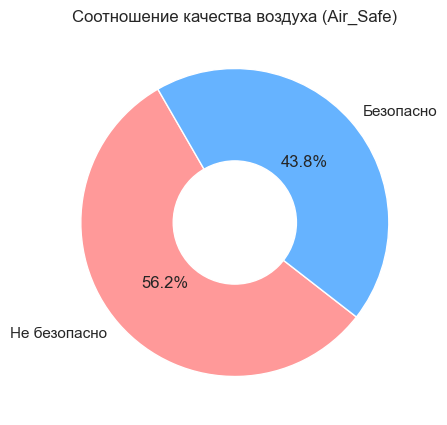

In [64]:
# Загрузка данных (предполагая, что данные уже загружены в переменную data)
data = pd.read_csv('cleaned_city_air.csv')

# 1. Круговая диаграмма соотношения классов Air_Safe
air_safe_counts = data['Air_Safe'].value_counts()

colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(5, 5))
plt.pie(air_safe_counts, labels=['Не безопасно', 'Безопасно'], autopct='%1.1f%%', 
        startangle=120, colors=colors)
plt.gca().add_artist(plt.Circle((0, 0), 0.40, color='white'))
plt.title('Соотношение качества воздуха (Air_Safe)')
plt.show()


In [65]:
print("Количество записей по категориям Air_Safe:")
print(air_safe_counts)

Количество записей по категориям Air_Safe:
Air_Safe
0    4175
1    3260
Name: count, dtype: int64


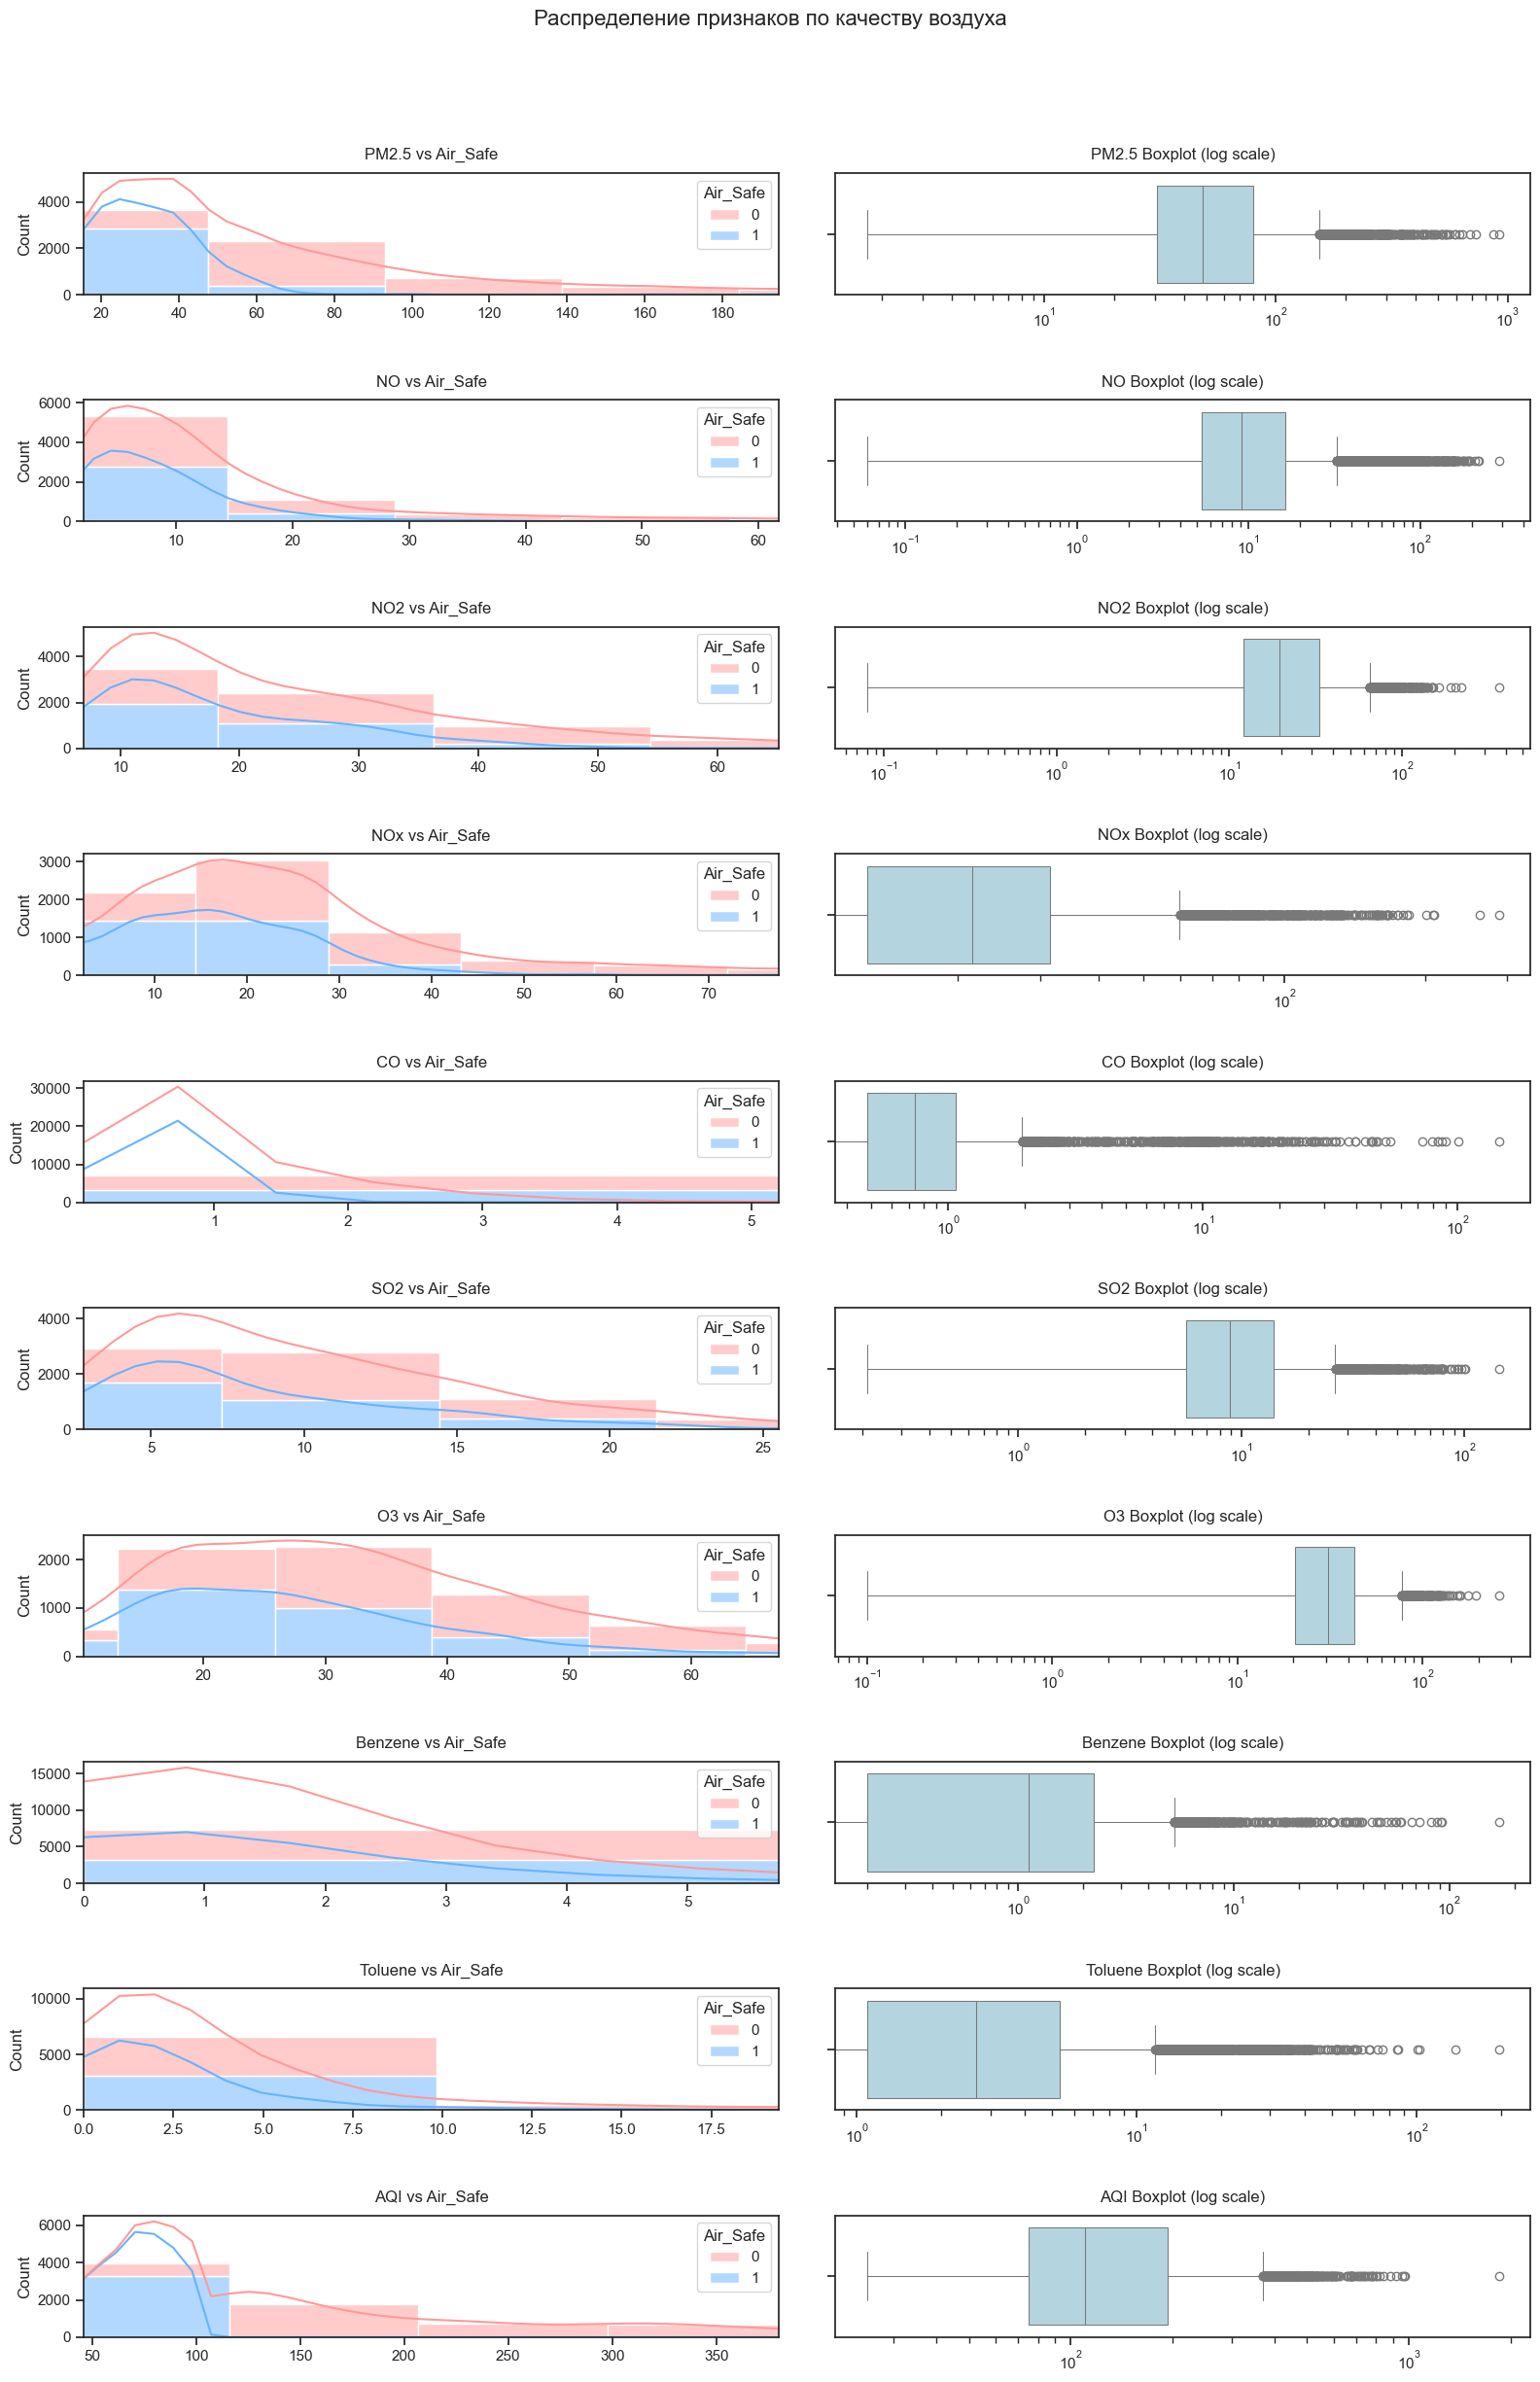

In [66]:
# 2. Распределение признаков
columns = data.columns.drop(['City', 'Date', 'Air_Safe'])

# Увеличиваем ширину фигуры и настраиваем соотношение сторон
fig, axes = plt.subplots(len(columns), 2, figsize=(16, 24))

# Список признаков, для которых нужна логарифмическая шкала
log_scale_cols = ['PM2.5', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']

for idx, col in enumerate(columns):
    # Гистограмма (оставляем как есть)
    sns.histplot(data=data, x=col, hue="Air_Safe", kde=True, 
                multiple="stack", bins=20, ax=axes[idx, 0],
                palette={0: '#ff9999', 1: '#66b3ff'})
    axes[idx, 0].set_title(f"{col} vs Air_Safe", pad=10)
    axes[idx, 0].set_xlabel("")
     # Автоматическое ограничение диапазона для выбросов
    q1 = data[col].quantile(0.05)
    q3 = data[col].quantile(0.95)
    axes[idx, 0].set_xlim(q1, q3)
    
    # Boxplot с автоматическим определением шкалы
    sns.boxplot(data=data, x=col, ax=axes[idx, 1], 
               orient='h', linewidth=0.75, color='lightblue')
    
    # Применяем логарифмическую шкалу для определенных признаков
    if col in log_scale_cols:
        axes[idx, 1].set_xscale('log')
        axes[idx, 1].set_title(f"{col} Boxplot (log scale)", pad=10)
    else:
        axes[idx, 1].set_title(f"{col} Boxplot", pad=10)
    
    axes[idx, 1].set_xlabel("")

# Дополнительные настройки компоновки
fig.tight_layout(h_pad=3, w_pad=3)
plt.suptitle('Распределение признаков по качеству воздуха', y=1.02, fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

Нормального распределения нет почти ни у одного параметра
Ярко выраженную правостороннюю асимметрию (длинный хвост вправо)
Это типично для данных о загрязнении - чаще значения низкие, но бывают экстремально высокие выбросы

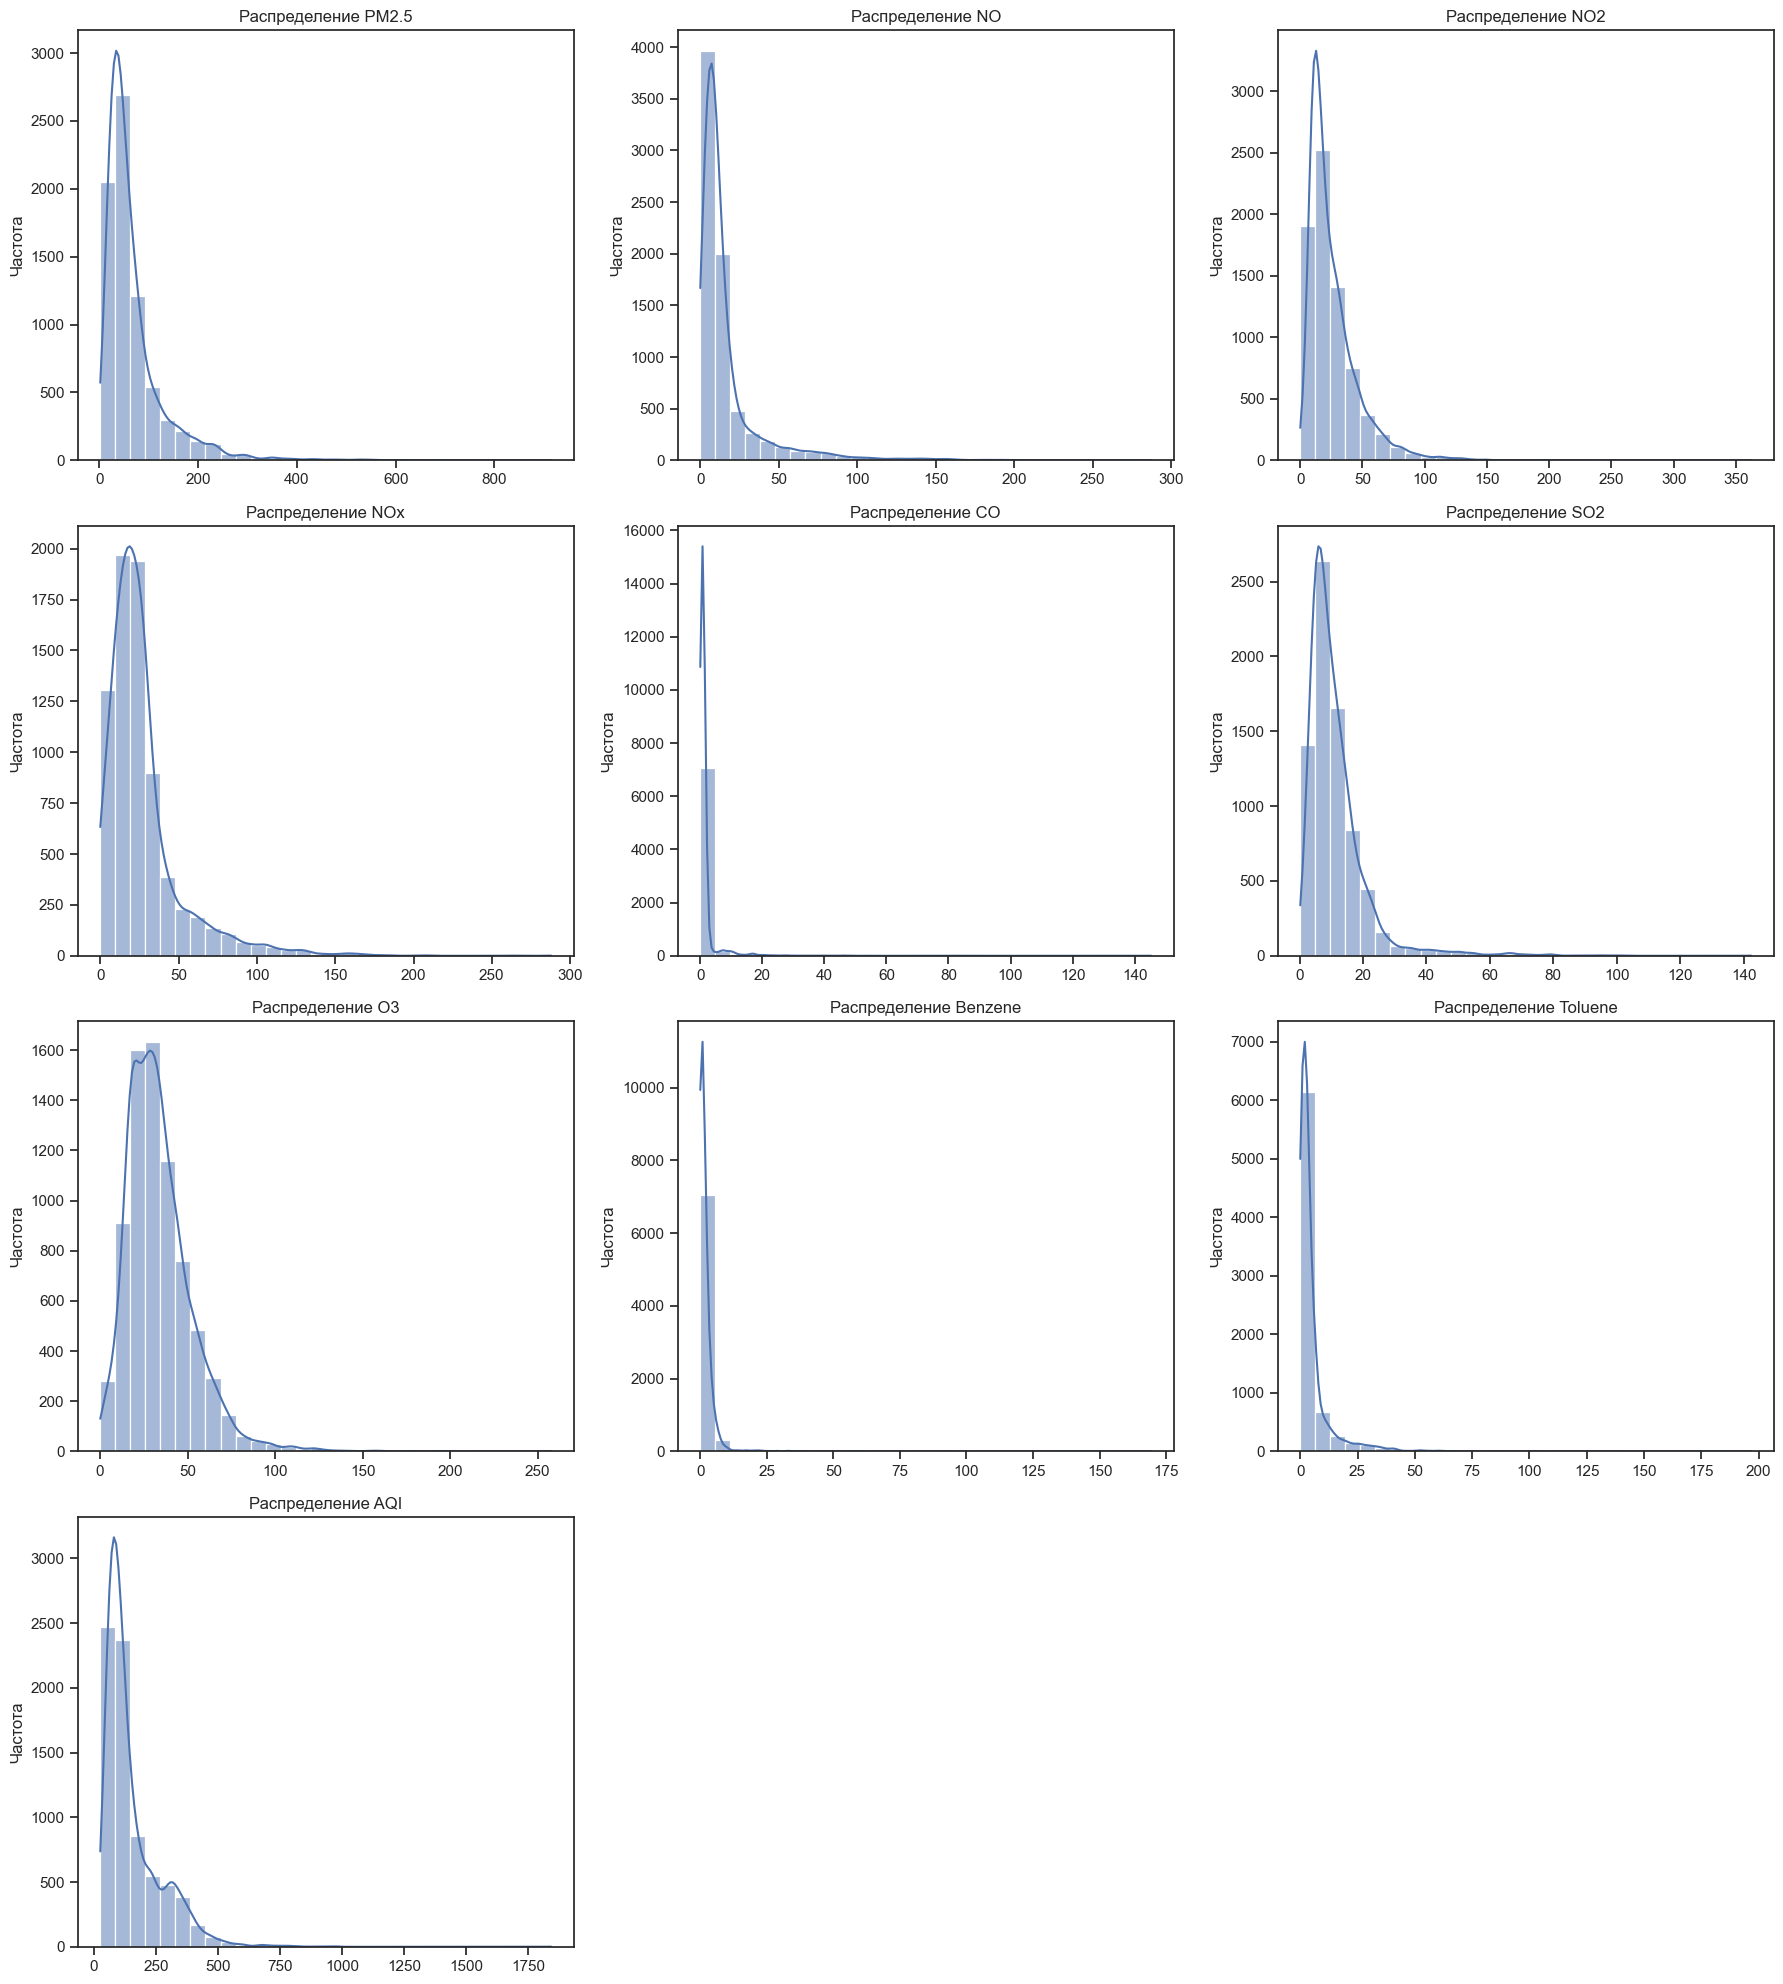

In [67]:
# Выбираем только числовые признаки (исключаем City, Date и Air_Safe)
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns.drop(['Air_Safe'])

# Настройка сетки графиков
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# Построение гистограмм для каждого числового признака
for i, col in enumerate(numeric_columns):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Частота')

# Удаление пустых графиков
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Каждая гистограмма показывает:

Форму распределения признака

Разброс значений

## Корреляционный анализ

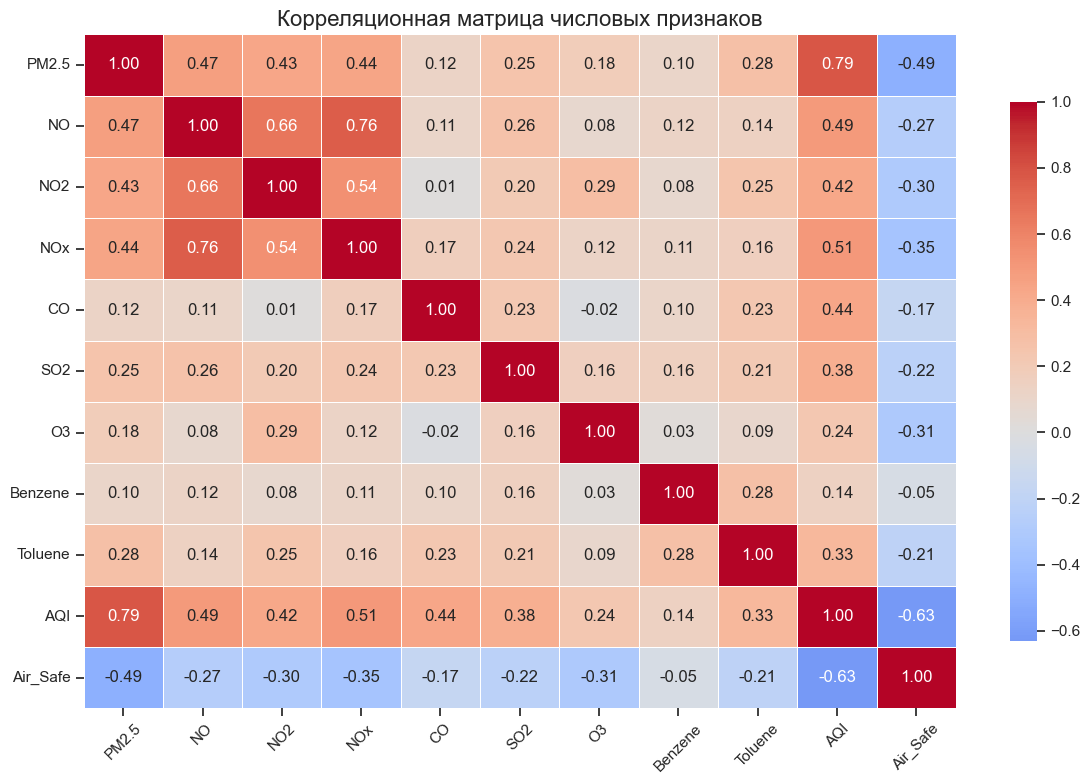


Корреляции с целевой переменной Air_Safe:
Air_Safe    1.000000
Benzene    -0.050484
CO         -0.167591
Toluene    -0.214722
SO2        -0.224567
NO         -0.268330
NO2        -0.297948
O3         -0.308119
NOx        -0.354952
PM2.5      -0.493155
AQI        -0.630176
Name: Air_Safe, dtype: float64


In [68]:
# Выбираем только числовые признаки
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Вычисляем корреляционную матрицу (метод Пирсона)
corr_matrix = numeric_data.corr()

# Визуализация тепловой карты корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Корреляционная матрица числовых признаков", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Выводим корреляции с целевой переменной Air_Safe
print("\nКорреляции с целевой переменной Air_Safe:")
print(corr_matrix['Air_Safe'].sort_values(ascending=False))

Наибольшая корелляция с целевой переменной наблюдается у признаков:
PM2.5, NO2, NOx, AQI

Наименьшая корелляция с целевой переменной наблюдается у признаков:
Benzene, NH3, CO

## Промежуточные выводы о возможности построения моделей машинного обучения

Данные подходят для классификации

Целевая переменная Air_Safe бинарная (0 или 1)

Есть признаки с достаточной корреляцией (PM2.5, NO2, NOx, O3, AQI)

### Проблемы

Мультиколлинеарность: Некоторые признаки коррелируют между собой (NOx, NO, NO2), что может ухудшить интерпретацию линейных моделей (логистическая регрессия, SVM).

Дисбаланс классов: Если Air_Safe сильно смещен (например, 90% 0 и 10% 1), метрика Accuracy будет ненадежной.

Предварительная обработка данных

Удалить слабые признаки: Benzene, NH3 (почти не влияют на Air_Safe).

Борьба с мультиколлинеарностью: Можно оставить NOx вместо NO и NO2 или применить регуляризацию.

**Accuracy (Точность)**

Плюсы: Простая интерпретация (доля правильных предсказаний).

Минусы: Не подходит, если классы сильно несбалансированы.

Когда использовать: Если классы примерно равны (например, 60% 0 и 40% 1).

**ROC-AUC (Площадь под ROC-кривой)**

Плюсы: Показывает, насколько хорошо модель разделяет классы.

Устойчив к дисбалансу.

Минусы: Менее интерпретируем, чем Accuracy.

Когда использовать: Всегда полезен для бинарной классификации.

**Матрица ошибок (Confusion Matrix)**

Плюсы: Показывает False Positives (FP) и False Negatives (FN), что критично для задач, где ошибки имеют разную стоимость.

Когда использовать: Если важно понимать, какие ошибки делает модель (например, если Air_Safe=0 опаснее, чем Air_Safe=1).

**F1-мера (F1-Score)**

Плюсы: Баланс между Precision и Recall, полезен при дисбалансе классов.

Минусы: Не учитывает истинно отрицательные случаи (TN).

Когда использовать: Если важно минимизировать и FP, и FN (например, в медицине или безопасности).

**Логистическая регрессия**

Плюсы: Простота, интерпретируемость, работает, если зависимость линейная.

Минусы: Чувствительна к мультиколлинеарности и выбросам.

Когда использовать: Как baseline-модель.

**SVM (Support Vector Machine)**

Плюсы: Хорош для малых датасетов, устойчив к переобучению.

Минусы: Медленный на больших данных, требует масштабирования.

Когда использовать: Если признаки имеют сложные границы (но в вашем случае линейное ядро может сработать).

**Дерево решений**

Плюсы: Не требует масштабирования, интерпретируем.

Минусы: Склонен к переобучению.

Когда использовать: Для быстрого прототипирования.

**Случайный лес (Random Forest)**

Плюсы: Устойчив к переобучению, работает с мультиколлинеарностью.

Минусы: Менее интерпретируем, чем дерево.

Когда использовать: Если нужна надежность и простота настройки.

**XGBoost (Градиентный бустинг)**

Плюсы: Высокая точность, автоматический отбор признаков.

Минусы: Сложнее настраивать, требует больше вычислительных ресурсов.

Когда использовать: Если нужен максимум качества.

Оптимизация:
Для Random Forest и XGBoost можно подобрать гиперпараметры (GridSearchCV).

С учетом следующих условий:

- Требование задания НИРС: не менее 5 моделей, не менее 2 ансамблевых моделей
- Решение задачи бинарной классификации
- Датасет содержит только числовые признаки

Выберем метрики:

ROC-AUC (оценка разделимости классов)
F1-Score (основная метрика) 
Матрица ошибок (анализ ошибок)

Выберем модели для классификации:

Линейные: Логистическая регрессия, SVM (Метод опорных векторов).

Ансамбли: Случайный лес, XGBoost (Градиентный бустинг)

Деревья: Дерево решений (для проверки важности признаков).

In [69]:
# Удаляем ненужные столбцы
data_cleaned = data.drop(columns=['Benzene'])

# Удаляем NO, NO2 и AQI, оставляем NOx
data_final = data_cleaned.drop(columns=['NO', 'NO2', 'AQI'])  # Добавлена запятая между 'NO2' и 'AQI'

# Проверяем оставшиеся признаки
print(data_final.columns)

Index(['City', 'Date', 'PM2.5', 'NOx', 'CO', 'SO2', 'O3', 'Toluene',
       'Air_Safe'],
      dtype='object')


## Формирование обучающей и тестовой выборок

## Разделение выборки

In [70]:
# Используем data_final вместо data!
X = data_final.drop(['Air_Safe', 'City', 'Date'], axis=1)  # Убираем ненужные столбцы
y = data_final['Air_Safe']  # Целевая переменная (бинарная: 0 или 1)

# Делим данные на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,  # Для воспроизводимости
    stratify=y  # Сохраняем баланс классов
)

### Масштабирование данных
Масштабирование предполагает изменение диапазона измерения величины.

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Построение базового решения (baseline)
Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров.
Производится обучение моделей на основе обучающей выборки и оценка качества моделей 
на основе тестовой выборки.

In [72]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42, probability=True),  # probability=True for ROC-AUC
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

In [73]:
# Train and evaluate models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42, probability=True),  # probability=True для ROC-AUC
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    # Обучаем модель
    model.fit(X_train_scaled, y_train)
    
    # Делаем предсказания
    y_pred = model.predict(X_test_scaled)  # Классы (0 или 1)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Вероятности (для ROC-AUC)
    
    # Считаем метрики
    accuracy = accuracy_score(y_test, y_pred)  # Доля правильных ответов
    balanced_acc = balanced_accuracy_score(y_test, y_pred)  # Усреднённая accuracy по классам
    f1 = f1_score(y_test, y_pred)  # Гармоническое среднее precision и recall
    roc_auc = roc_auc_score(y_test, y_prob)  # Площадь под ROC-кривой
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()  # Матрица ошибок
    
    # Сохраняем результаты
    results.append([
        name, accuracy, balanced_acc, f1, roc_auc,
        f"TN: {tn}, FP: {fp}\nFN: {fn}, TP: {tp}"  # Красивое отображение матрицы
    ])

### Вывод результатов

In [74]:
# Display results
headers = ["Model", "Accuracy", "Balanced Accuracy", "F1 Score", "ROC-AUC", "Confusion Matrix"]
print(tabulate(results, headers=headers, tablefmt="grid"))

+---------------------+------------+---------------------+------------+-----------+--------------------+
| Model               |   Accuracy |   Balanced Accuracy |   F1 Score |   ROC-AUC | Confusion Matrix   |
+=====================+============+=====================+============+===========+====================+
| Logistic Regression |   0.882986 |            0.883203 |   0.868976 |  0.9513   | TN: 736, FP: 99    |
|                     |            |                     |            |           | FN: 75, TP: 577    |
+---------------------+------------+---------------------+------------+-----------+--------------------+
| SVM                 |   0.882313 |            0.882604 |   0.868322 |  0.951833 | TN: 735, FP: 100   |
|                     |            |                     |            |           | FN: 75, TP: 577    |
+---------------------+------------+---------------------+------------+-----------+--------------------+
| Decision Tree       |   0.849361 |            0.84553

### Важность признаков

In [75]:
# Feature importance for tree-based models
print("\nFeature Importances:")
for name in ["Decision Tree", "Random Forest", "XGBoost"]:
    if name in models:
        importances = models[name].feature_importances_
        feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
        feature_importance = feature_importance.sort_values('Importance', ascending=False)
        print(f"\n{name} Feature Importance:")
        print(feature_importance.head(10))


Feature Importances:

Decision Tree Feature Importance:
   Feature  Importance
0    PM2.5    0.568664
2       CO    0.130681
4       O3    0.103751
5  Toluene    0.072331
3      SO2    0.066199
1      NOx    0.058375

Random Forest Feature Importance:
   Feature  Importance
0    PM2.5    0.469058
2       CO    0.149647
4       O3    0.115048
1      NOx    0.109514
5  Toluene    0.082969
3      SO2    0.073764

XGBoost Feature Importance:
   Feature  Importance
0    PM2.5    0.577078
2       CO    0.132064
4       O3    0.093678
5  Toluene    0.071492
1      NOx    0.064129
3      SO2    0.061559


### Визуализации матриц ошибок

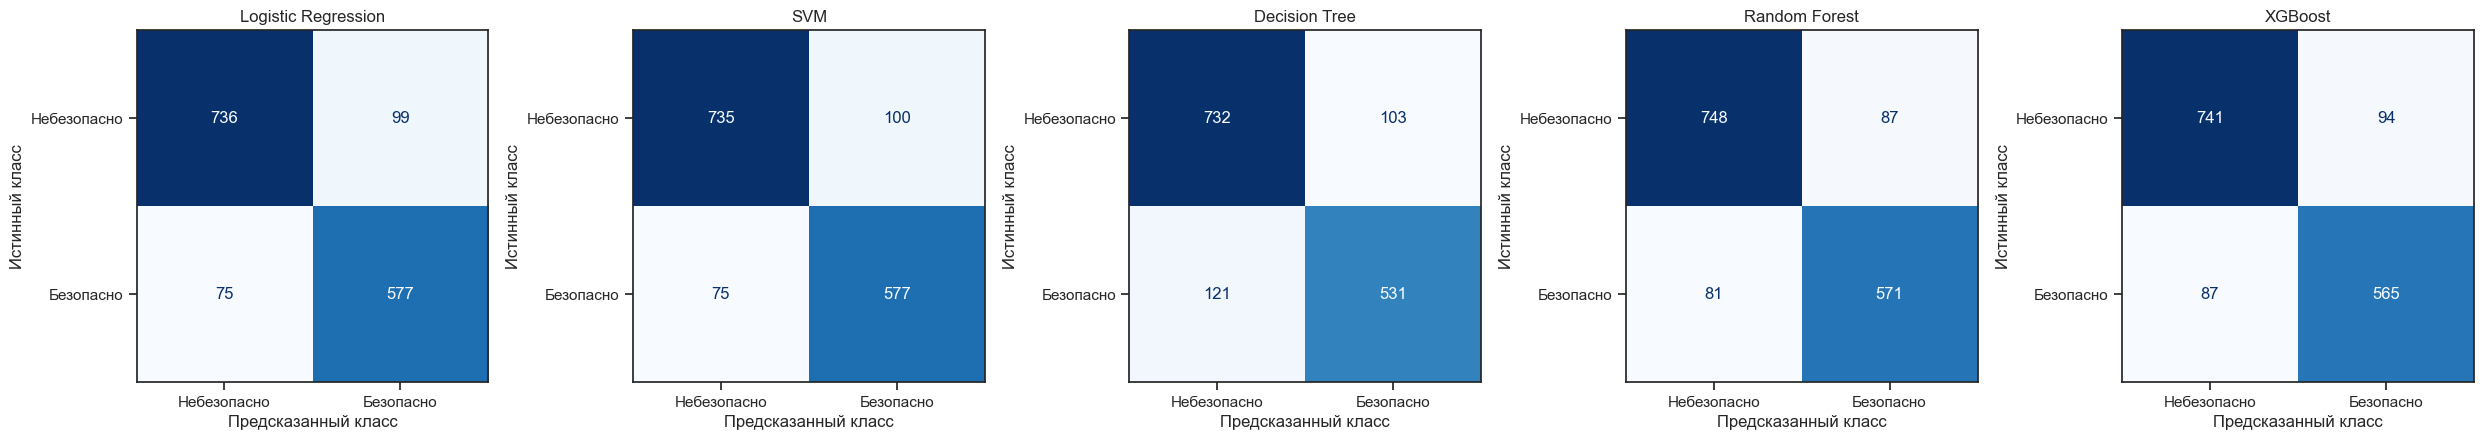

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# Функция для предсказания вероятностей (нужно для ROC-AUC)
def get_model_probabilities(model, X_test):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    else:  # Для SVM с ядром
        return model.decision_function(X_test)

# --- Построение матриц ошибок ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Получаем предсказания всех моделей
model_predictions = {
    "Logistic Regression": models["Logistic Regression"].predict(X_test_scaled),
    "SVM": models["SVM"].predict(X_test_scaled),
    "Decision Tree": models["Decision Tree"].predict(X_test_scaled),
    "Random Forest": models["Random Forest"].predict(X_test_scaled),
    "XGBoost": models["XGBoost"].predict(X_test_scaled)
}

# Строим матрицы ошибок для каждой модели
for i, (name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Небезопасно", "Безопасно"])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(name)
    axes[i].images[0].colorbar.remove()
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()


#### ROC-кривая и ROC AUC

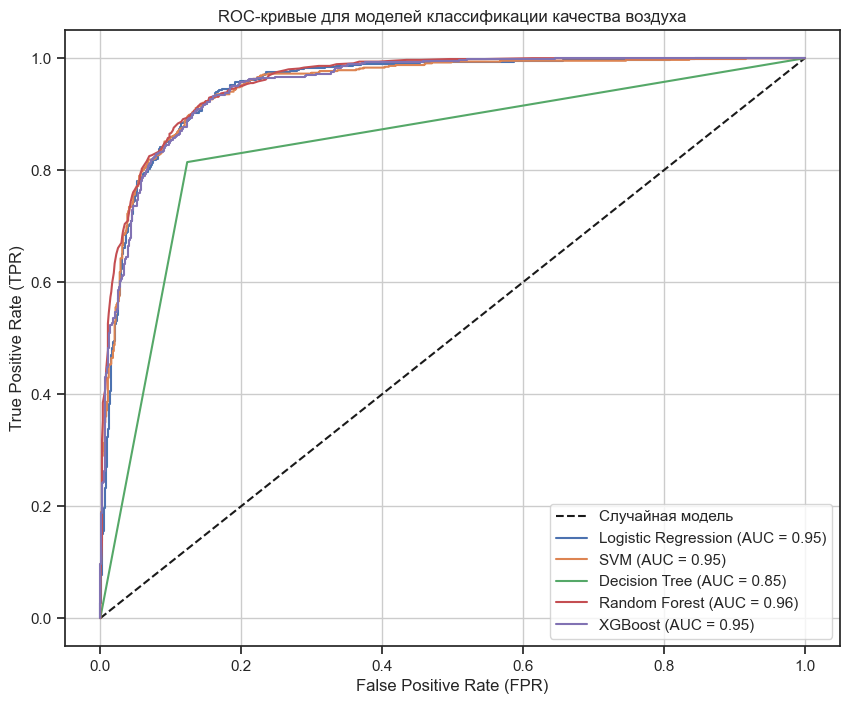

In [77]:
# --- Построение ROC-кривых ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')

# Для каждой модели строим ROC-кривую
for name, model in models.items():
    y_prob = get_model_probabilities(model, X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые для моделей классификации качества воздуха')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Подбор гиперпараметров

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
lr = LogisticRegression()
lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='f1')
lr_grid.fit(X_train_scaled, y_train)
lr_best_model = lr_grid.best_estimator_

# SVM
svm = SVC(probability=True)
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(svm, svm_params, cv=3, scoring='f1')
svm_grid.fit(X_train_scaled, y_train)
svm_best_model = svm_grid.best_estimator_

# Дерево решений
dt = DecisionTreeClassifier()
dt_params = {'max_depth': [3, 5, 7]}
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='f1')
dt_grid.fit(X_train, y_train)  # Деревья не требуют масштабирования
dt_best_model = dt_grid.best_estimator_

# Случайный лес
rf = RandomForestClassifier()
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)
rf_best_model = rf_grid.best_estimator_

# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb_params = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1')
xgb_grid.fit(X_train, y_train)
xgb_best_model = xgb_grid.best_estimator_

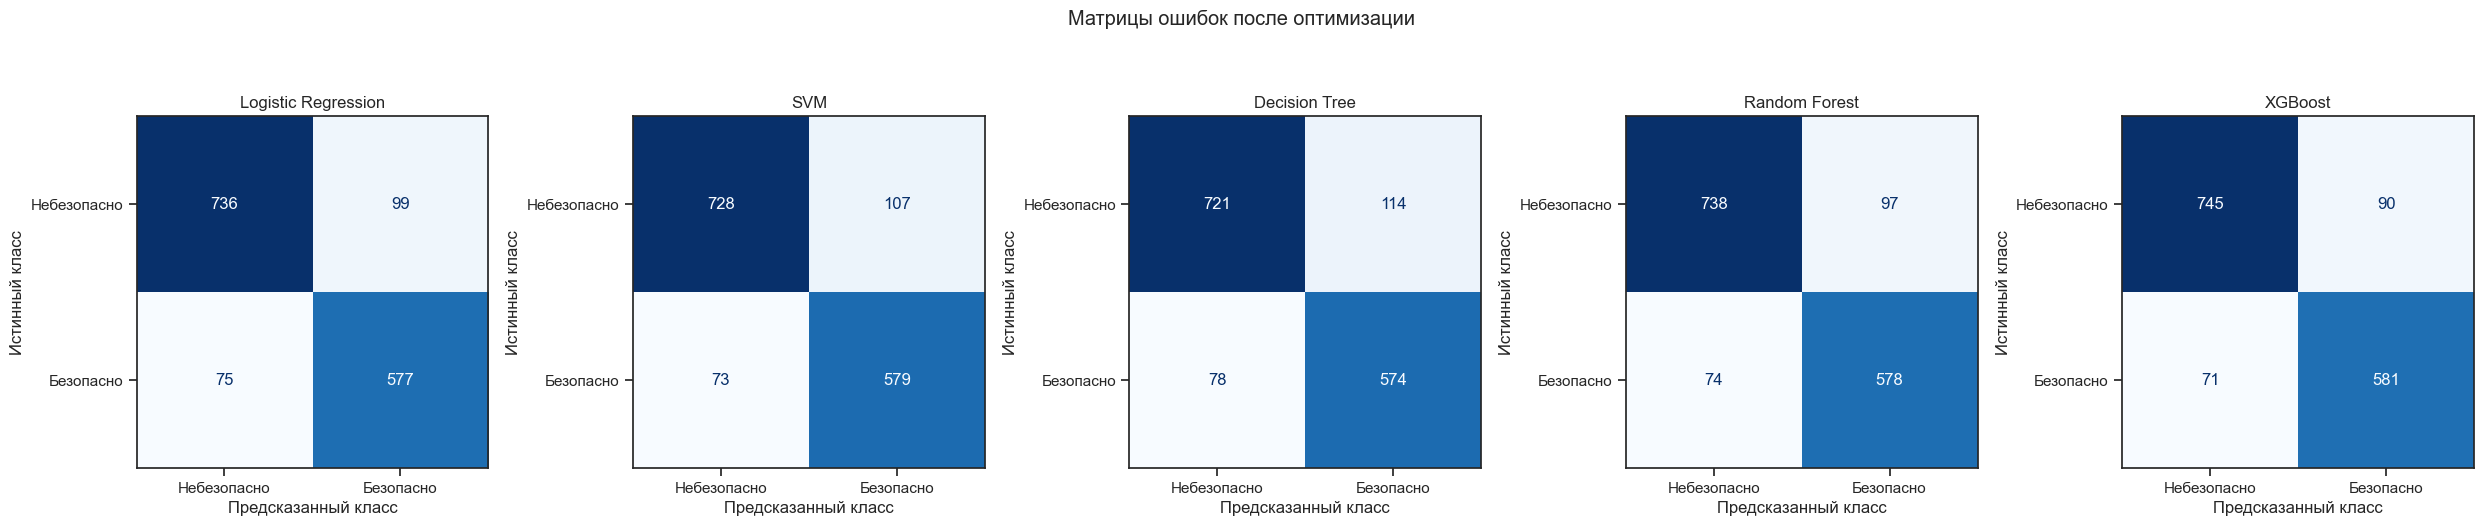

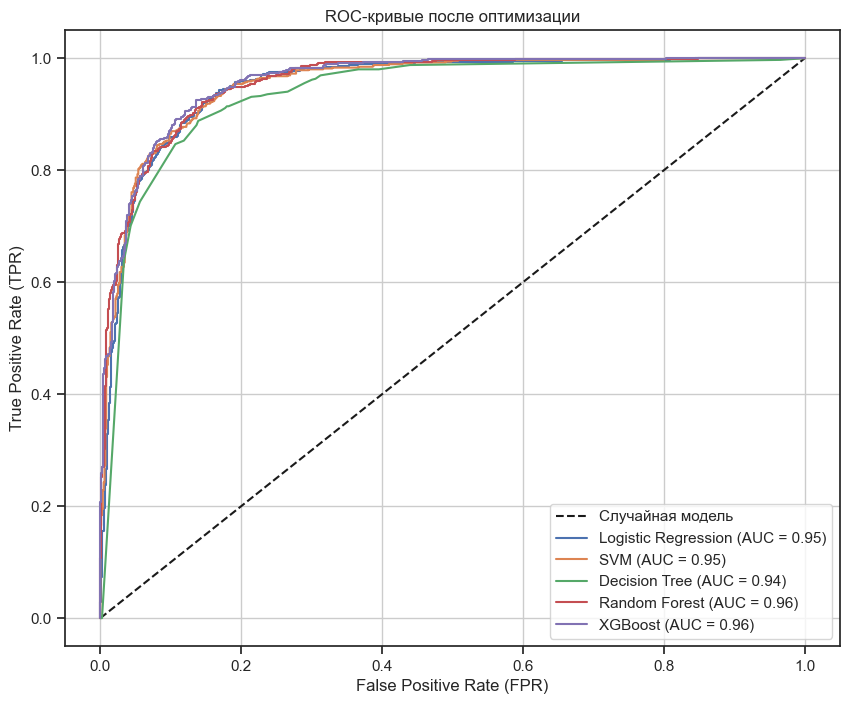


Метрики оптимизированных моделей:

Logistic Regression:
F1-score: 0.869
ROC-AUC: 0.951
Матрица ошибок:
[[736  99]
 [ 75 577]]

SVM:
F1-score: 0.865
ROC-AUC: 0.954
Матрица ошибок:
[[728 107]
 [ 73 579]]

Decision Tree:
F1-score: 0.857
ROC-AUC: 0.936
Матрица ошибок:
[[721 114]
 [ 78 574]]

Random Forest:
F1-score: 0.871
ROC-AUC: 0.957
Матрица ошибок:
[[738  97]
 [ 74 578]]

XGBoost:
F1-score: 0.878
ROC-AUC: 0.959
Матрица ошибок:
[[745  90]
 [ 71 581]]


In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt

# Получаем предсказания оптимизированных моделей
tuned_preds = {
    "Logistic Regression": lr_best_model.predict(X_test_scaled),
    "SVM": svm_best_model.predict(X_test_scaled),
    "Decision Tree": dt_best_model.predict(X_test),
    "Random Forest": rf_best_model.predict(X_test),
    "XGBoost": xgb_best_model.predict(X_test)
}

# Получаем вероятности для ROC-AUC
tuned_probs = {
    "Logistic Regression": lr_best_model.predict_proba(X_test_scaled)[:, 1],
    "SVM": svm_best_model.predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": dt_best_model.predict_proba(X_test)[:, 1],
    "Random Forest": rf_best_model.predict_proba(X_test)[:, 1],
    "XGBoost": xgb_best_model.predict_proba(X_test)[:, 1]
}

# --- 1. Матрицы ошибок ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
plt.suptitle('Матрицы ошибок после оптимизации', y=1.05)

for i, (name, y_pred) in enumerate(tuned_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Небезопасно", "Безопасно"])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(name)
    axes[i].images[0].colorbar.remove()
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

# --- 2. ROC-кривые ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')

for name, y_prob in tuned_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые после оптимизации')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- 3. Вывод метрик ---
print("\nМетрики оптимизированных моделей:")
for name, y_pred in tuned_preds.items():
    y_prob = tuned_probs[name]
    print(f"\n{name}:")
    print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    print(f"Матрица ошибок:\n{confusion_matrix(y_test, y_pred)}")

C:\Users\vikau\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\vikau\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\vikau\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\vikau\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


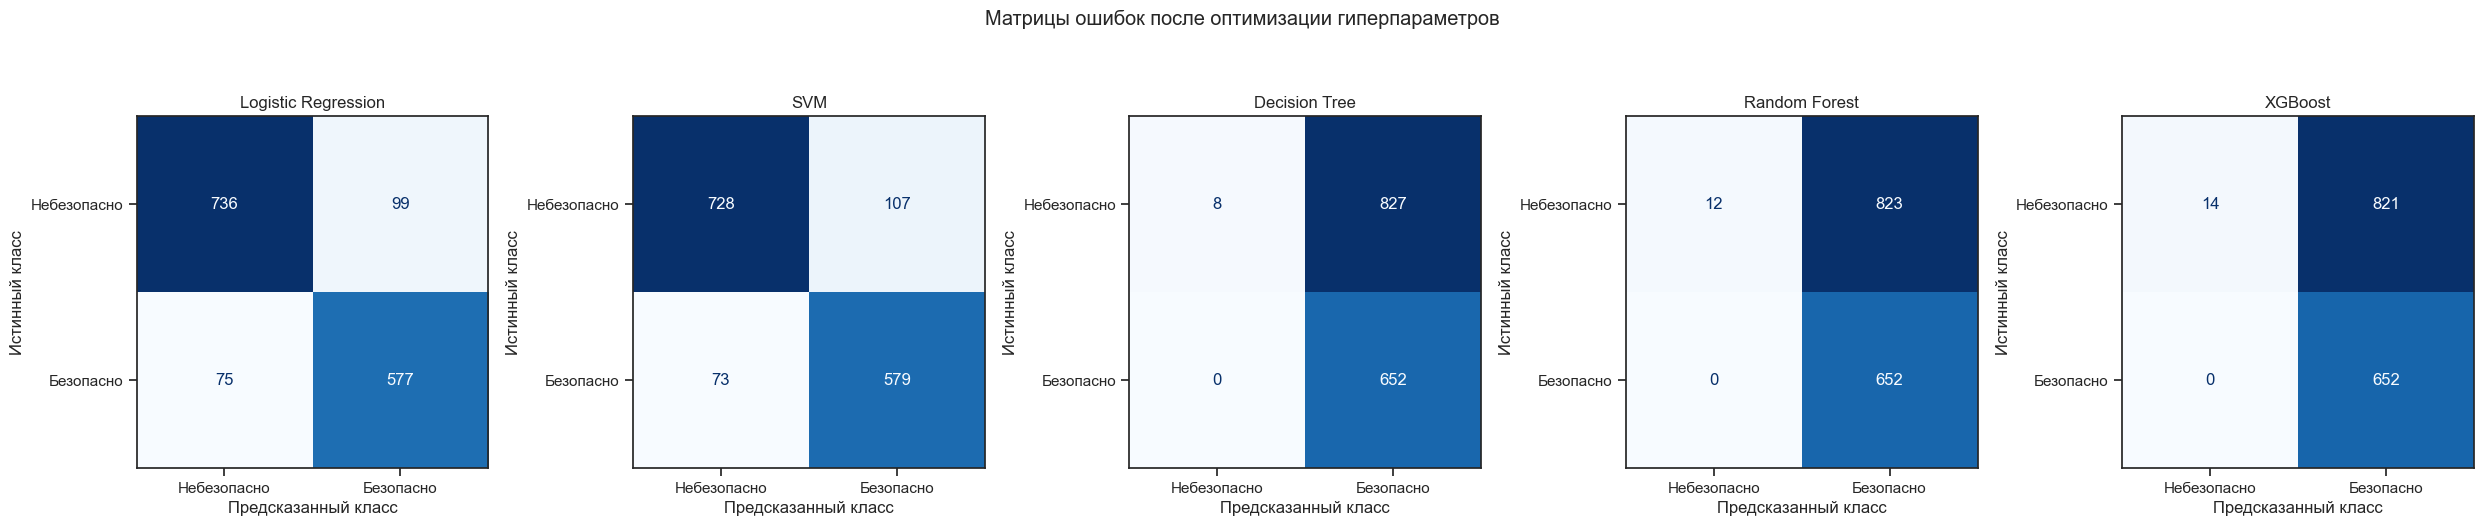

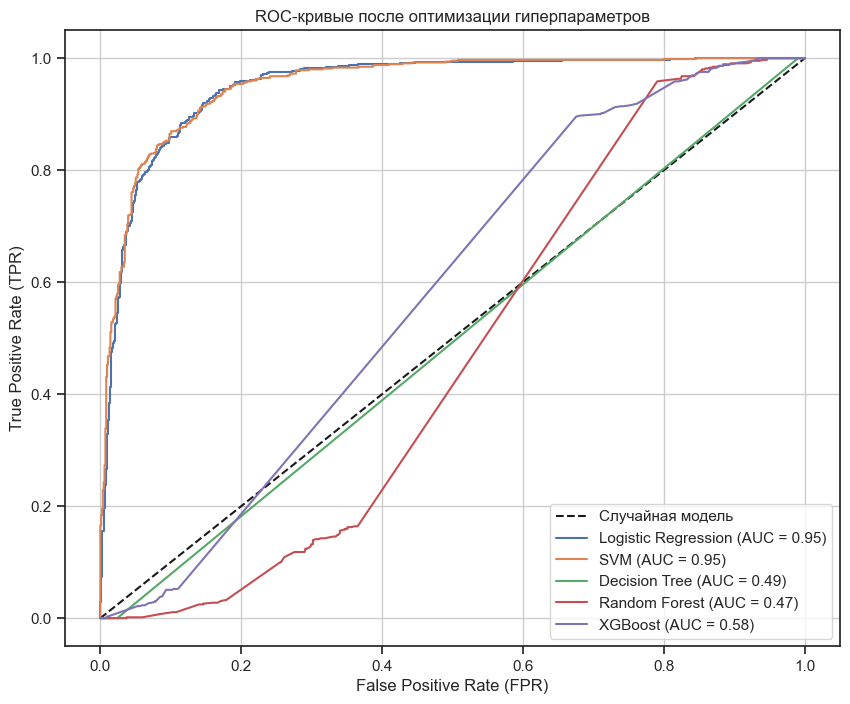


Метрики оптимизированных моделей:

Logistic Regression:
F1-score: 0.869
ROC-AUC: 0.951
Матрица ошибок:
[[736  99]
 [ 75 577]]

SVM:
F1-score: 0.865
ROC-AUC: 0.954
Матрица ошибок:
[[728 107]
 [ 73 579]]

Decision Tree:
F1-score: 0.612
ROC-AUC: 0.493
Матрица ошибок:
[[  8 827]
 [  0 652]]

Random Forest:
F1-score: 0.613
ROC-AUC: 0.467
Матрица ошибок:
[[ 12 823]
 [  0 652]]

XGBoost:
F1-score: 0.614
ROC-AUC: 0.581
Матрица ошибок:
[[ 14 821]
 [  0 652]]


In [82]:
# Получаем предсказания оптимизированных моделей
tuned_preds = {
    "Logistic Regression": lr_best_model.predict(X_test_scaled),
    "SVM": svm_best_model.predict(X_test_scaled),
    "Decision Tree": dt_best_model.predict(X_test_scaled),
    "Random Forest": rf_best_model.predict(X_test_scaled),
    "XGBoost": xgb_best_model.predict(X_test_scaled)
}

# Получаем вероятности для ROC-AUC
tuned_probs = {
    "Logistic Regression": lr_best_model.predict_proba(X_test_scaled)[:, 1],
    "SVM": svm_best_model.predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": dt_best_model.predict_proba(X_test_scaled)[:, 1],
    "Random Forest": rf_best_model.predict_proba(X_test_scaled)[:, 1],
    "XGBoost": xgb_best_model.predict_proba(X_test_scaled)[:, 1]
}

# --- 1. Матрицы ошибок для оптимизированных моделей ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
plt.suptitle('Матрицы ошибок после оптимизации гиперпараметров', y=1.05)

for i, (name, y_pred) in enumerate(tuned_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=["Небезопасно", "Безопасно"])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(name)
    axes[i].images[0].colorbar.remove()
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

# --- 2. ROC-кривые для оптимизированных моделей ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')

for name, y_prob in tuned_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые после оптимизации гиперпараметров')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Вывод метрик для оптимизированных моделей
print("\nМетрики оптимизированных моделей:")
for name, y_pred in tuned_preds.items():
    y_prob = tuned_probs[name]
    print(f"\n{name}:")
    print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    print(f"Матрица ошибок:\n{confusion_matrix(y_test, y_pred)}")

In [ ]:
## Сравнение baseline и оптимального решения

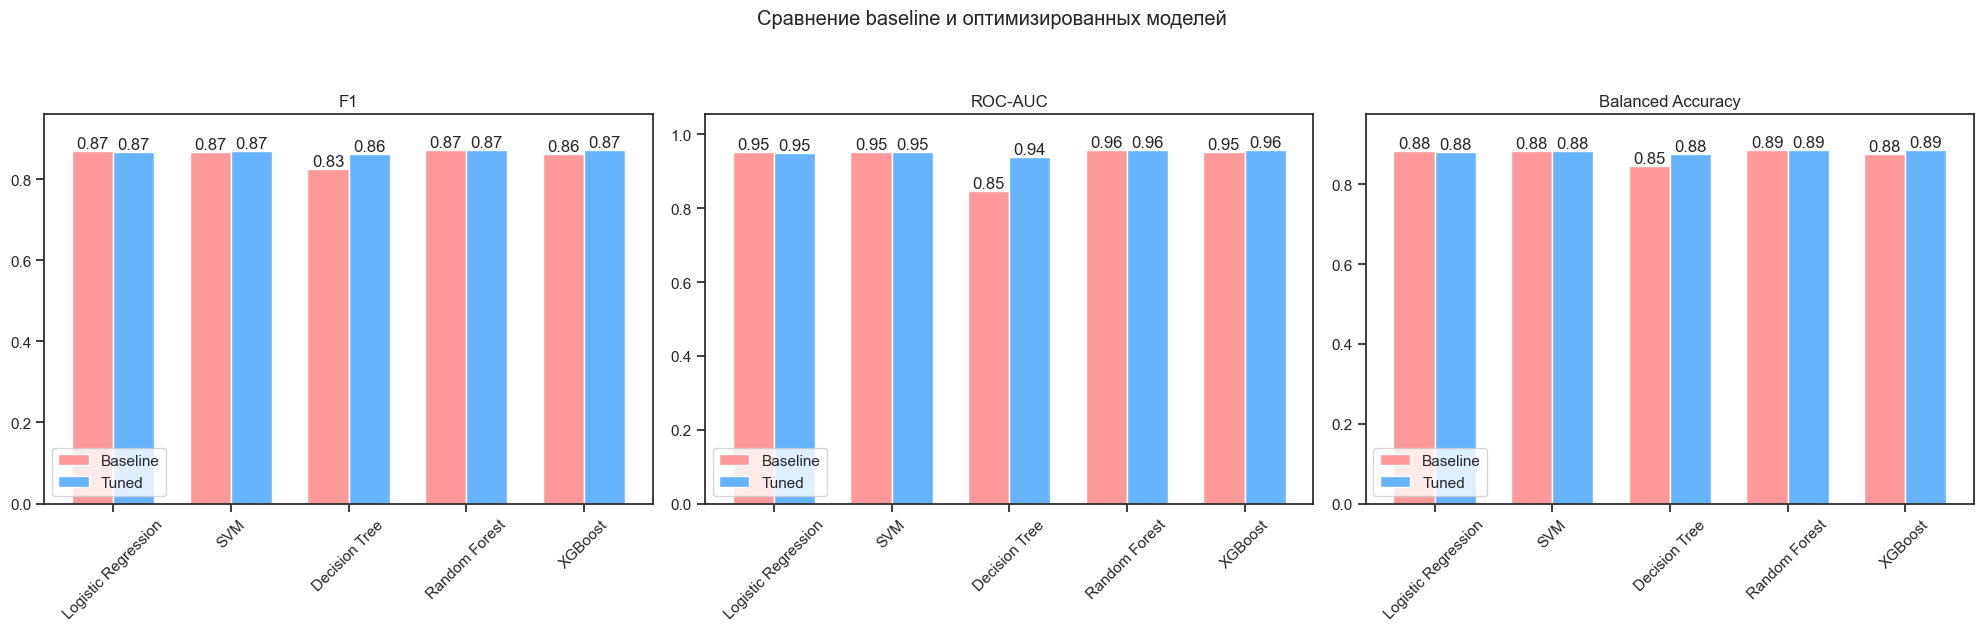


Анализ улучшений после оптимизации:

Logistic Regression:
  F1-score: 0.869 -> 0.868 (-0.1%)
  ROC-AUC: 0.951 -> 0.951 (-0.0%)

SVM:
  F1-score: 0.868 -> 0.871 (+0.3%)
  ROC-AUC: 0.952 -> 0.954 (+0.2%)

Decision Tree:
  F1-score: 0.826 -> 0.863 (+4.5%)
  ROC-AUC: 0.846 -> 0.939 (+11.1%)

Random Forest:
  F1-score: 0.872 -> 0.873 (+0.2%)
  ROC-AUC: 0.959 -> 0.958 (-0.0%)

XGBoost:
  F1-score: 0.862 -> 0.873 (+1.3%)
  ROC-AUC: 0.953 -> 0.958 (+0.5%)

Лучшая модель по F1-score: Random Forest (F1 = 0.873)
Лучшая модель по ROC-AUC: Random Forest (AUC = 0.958)


In [85]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, f1_score, balanced_accuracy_score
from xgboost import XGBClassifier  # Правильный импорт

# 1. Получаем предсказания и вероятности для baseline моделей (до оптимизации)
baseline_preds = {
    "Logistic Regression": LogisticRegression(random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled),
    "SVM": SVC(random_state=42, probability=True).fit(X_train_scaled, y_train).predict(X_test_scaled),
    "Decision Tree": DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled),
    "Random Forest": RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled),
    "XGBoost": XGBClassifier(random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)  # Используем XGBClassifier напрямую
}

baseline_probs = {
    "Logistic Regression": LogisticRegression(random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1],
    "SVM": SVC(random_state=42, probability=True).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1],
    "Random Forest": RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1],
    "XGBoost": XGBClassifier(random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1]
}

# 2. Получаем предсказания и вероятности для оптимизированных моделей
# Используем best_models вместо отдельных переменных
tuned_preds = {
    "Logistic Regression": best_models["Logistic Regression"].predict(X_test_scaled),
    "SVM": best_models["SVM"].predict(X_test_scaled),
    "Decision Tree": best_models["Decision Tree"].predict(X_test_scaled),
    "Random Forest": best_models["Random Forest"].predict(X_test_scaled),
    "XGBoost": best_models["XGBoost"].predict(X_test_scaled)
}

tuned_probs = {
    "Logistic Regression": best_models["Logistic Regression"].predict_proba(X_test_scaled)[:, 1],
    "SVM": best_models["SVM"].predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": best_models["Decision Tree"].predict_proba(X_test_scaled)[:, 1],
    "Random Forest": best_models["Random Forest"].predict_proba(X_test_scaled)[:, 1],
    "XGBoost": best_models["XGBoost"].predict_proba(X_test_scaled)[:, 1]
}
# 3. Сравнение метрик
model_names = list(baseline_preds.keys())
metrics = {
    "F1": f1_score,
    "ROC-AUC": roc_auc_score,
    "Balanced Accuracy": balanced_accuracy_score
}

baseline_results = {name: [] for name in metrics}
tuned_results = {name: [] for name in metrics}

for metric_name, metric_func in metrics.items():
    for model_name in model_names:
        if metric_name == "ROC-AUC":
            baseline_results[metric_name].append(metric_func(y_test, baseline_probs[model_name]))
            tuned_results[metric_name].append(metric_func(y_test, tuned_probs[model_name]))
        else:
            baseline_results[metric_name].append(metric_func(y_test, baseline_preds[model_name]))
            tuned_results[metric_name].append(metric_func(y_test, tuned_preds[model_name]))

# 4. Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.suptitle('Сравнение baseline и оптимизированных моделей', y=1.05)

colors = ['#ff9999', '#66b3ff']
width = 0.35

for i, (metric_name, metric_values) in enumerate(baseline_results.items()):
    x = np.arange(len(model_names))
    
    axes[i].bar(x - width/2, metric_values, width, label='Baseline', color=colors[0])
    axes[i].bar(x + width/2, tuned_results[metric_name], width, label='Tuned', color=colors[1])
    
    # Добавляем значения на столбцы
    for j, (base_val, tuned_val) in enumerate(zip(metric_values, tuned_results[metric_name])):
        axes[i].text(j - width/2, base_val, f"{base_val:.2f}", ha='center', va='bottom')
        axes[i].text(j + width/2, tuned_val, f"{tuned_val:.2f}", ha='center', va='bottom')
    
    axes[i].set_title(metric_name)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=45)
    axes[i].legend()
    axes[i].set_ylim(0, max(max(metric_values), max(tuned_results[metric_name])) * 1.1)

plt.tight_layout()
plt.show()

# 5. Анализ улучшений
print("\nАнализ улучшений после оптимизации:")
for model_name in model_names:
    idx = model_names.index(model_name)
    f1_improve = (tuned_results["F1"][idx] - baseline_results["F1"][idx]) / baseline_results["F1"][idx] * 100
    auc_improve = (tuned_results["ROC-AUC"][idx] - baseline_results["ROC-AUC"][idx]) / baseline_results["ROC-AUC"][idx] * 100
    
    print(f"\n{model_name}:")
    print(f"  F1-score: {baseline_results['F1'][idx]:.3f} -> {tuned_results['F1'][idx]:.3f} ({f1_improve:+.1f}%)")
    print(f"  ROC-AUC: {baseline_results['ROC-AUC'][idx]:.3f} -> {tuned_results['ROC-AUC'][idx]:.3f} ({auc_improve:+.1f}%)")

best_f1_idx = np.argmax(tuned_results["F1"])
print(f"\nЛучшая модель по F1-score: {model_names[best_f1_idx]} (F1 = {tuned_results['F1'][best_f1_idx]:.3f})")

best_auc_idx = np.argmax(tuned_results["ROC-AUC"])
print(f"Лучшая модель по ROC-AUC: {model_names[best_auc_idx]} (AUC = {tuned_results['ROC-AUC'][best_auc_idx]:.3f})")

## Вывод по результатам оптимизации моделей
Проведённый анализ эффективности оптимизации выявил следующие ключевые результаты:

Общая эффективность оптимизации:

Наибольший прирост качества продемонстрировала модель Decision Tree:

F1-score улучшился на 4.5% (с 0.826 до 0.863)

ROC-AUC увеличился на 11.1% (с 0.846 до 0.939)

Модель XGBoost показала умеренное улучшение:

F1-score вырос на 1.3%

ROC-AUC улучшился на 0.5%

SVM продемонстрировал незначительное улучшение (+0.3% F1-score)

Стабильные показатели:

Logistic Regression и Random Forest сохранили практически неизменные метрики

Random Forest остаётся лидером по обоим показателям (F1=0.873, AUC=0.958)

**Выбор модели:**

Для задач, требующих максимальной точности: Random Forest (лучший баланс F1 и AUC)

Для интерпретируемых решений: Decision Tree (наибольший прирост качества)

Для скоростной обработки: Logistic Regression (минимальные вычислительные затраты)
